# Notebook 03 — Barren Plateau Analysis

**Project:** Quantum Attention Mechanism Benchmark  
**Author:** Sarah Assou  
**Goal:** Measure whether each VQC architecture suffers from barren plateaus — the gradient vanishing problem that makes quantum circuits untrainable.

---

## What this notebook covers

1. **Theory** — what are barren plateaus and why do they matter for attention?
2. **Gradient variance measurement** — the standard diagnostic
3. **Depth sweep** — how gradient variance decays as layers increase
4. **Width sweep** — how gradient variance decays as qubits increase
5. **The expressibility–trainability tradeoff** — connecting Notebooks 02 and 03

---

> 📖 **Reference:** McClean, J. R., Boixo, S., Smelyanskiy, V. N., Babbush, R., & Neven, H. (2018).  
> *Barren plateaus in quantum neural network training landscapes.*  
> Nature Communications, 9(1), 4812. https://arxiv.org/abs/1803.11173

---

## Theory: What Are Barren Plateaus?

### The problem

When you train a VQC with gradient descent, you compute:
$$\frac{\partial \mathcal{L}}{\partial \theta_k}$$
for each parameter $\theta_k$ and update it accordingly.

A **barren plateau** occurs when these gradients become exponentially small as the circuit grows:
$$\text{Var}\left[\frac{\partial \mathcal{L}}{\partial \theta_k}\right] \leq F(n, L) \xrightarrow{n,L\to\infty} 0$$

When the gradient variance is near zero, gradient-based optimizers (Adam, SGD) see a completely flat loss landscape — they can't determine which direction to move. Training stalls entirely.

### Why highly expressive circuits are most at risk

McClean et al. (2018) proved that for circuits forming approximate 2-designs (i.e., highly expressive circuits like SEL), the gradient variance decays **exponentially** with the number of qubits:

$$\text{Var}\left[\frac{\partial \mathcal{L}}{\partial \theta_k}\right] \sim \frac{1}{2^n}$$

This means: **the more expressive a circuit is, the more likely it is to have vanishing gradients.**

This is the central tension in your benchmark:
- SEL is most expressive → likely worst barren plateaus
- HEA is least expressive → likely best trainability

### The diagnostic

We measure **gradient variance** across many random parameter initializations:
$$\hat{\text{Var}}\left[\frac{\partial \mathcal{L}}{\partial \theta_0}\right] = \frac{1}{N_{\text{init}}}\sum_{i=1}^{N_{\text{init}}} \left(\frac{\partial \mathcal{L}}{\partial \theta_0}\Big|_{\theta^{(i)}} - \bar{g}\right)^2$$

If this variance decays exponentially with depth/width → barren plateau.

---
## Cell 1 — Setup

In [1]:
!pip install pennylane pennylane-lightning matplotlib numpy torch --quiet
print("✅ Ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 101.1 MB/s eta 0:00:00
✅ Ready.


In [2]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

# ── Configuration ───────────────────────────────────────────────────────────
N_QUBITS      = 4      # Baseline qubit count
N_LAYERS      = 2      # Baseline layer count
N_INITS       = 200    # Random initializations for gradient variance
MAX_LAYERS_BP = 8      # Max layers for depth sweep
MAX_QUBITS_BP = 8      # Max qubits for width sweep

print(f"Baseline: {N_QUBITS} qubits, {N_LAYERS} layers")
print(f"Gradient variance over {N_INITS} random initializations")
print("✅ Setup complete.")

Baseline: 4 qubits, 2 layers
Gradient variance over 200 random initializations
✅ Setup complete.


---
## Cell 2 — Circuit + Gradient Functions

In [3]:
# ── Gradient variance measurement ───────────────────────────────────────────

def make_circuits(n_qubits, n_layers):
    """
    Create all three circuits for a given qubit/layer configuration.
    Returns (sel_fn, iqp_fn, hea_fn) — each returns a scalar expectation value
    suitable for gradient computation.
    """
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, diff_method="parameter-shift")
    def sel_circuit(weights):
        # No input encoding — we measure gradient wrt parameters only
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        # Global cost function: sum of Z measurements (most susceptible to barren plateaus)
        return qml.expval(qml.PauliZ(0))

    @qml.qnode(dev, diff_method="parameter-shift")
    def iqp_circuit(weights):
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RX(0.0, wires=i)  # No input for pure parameter analysis
                qml.RZ(weights[layer, i, 0], wires=i)
            for i in range(n_qubits):
                qml.IsingZZ(weights[layer, i, 1], wires=[i, (i+1) % n_qubits])
            for i in range(n_qubits):
                qml.Hadamard(wires=i)
        return qml.expval(qml.PauliZ(0))

    @qml.qnode(dev, diff_method="parameter-shift")
    def hea_circuit(weights):
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
                qml.RZ(weights[layer, i, 1], wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i+1])
        return qml.expval(qml.PauliZ(0))

    return sel_circuit, iqp_circuit, hea_circuit


def measure_gradient_variance(circuit_fn, weight_shape, n_inits=N_INITS):
    """
    Measure the variance of the gradient of the FIRST parameter across
    many random initializations.

    This is the standard barren plateau diagnostic:
    - High variance → gradients are informative → trainable
    - Near-zero variance → gradients vanish → barren plateau

    Args:
        circuit_fn   : QNode function(weights) -> scalar
        weight_shape : tuple
        n_inits      : number of random initializations

    Returns:
        variance : float
        gradients: list of gradient values (for distribution plotting)
    """
    gradients = []

    for _ in range(n_inits):
        # Random initialization — uniform in [0, 2π]
        weights = pnp.array(
            np.random.uniform(0, 2*np.pi, weight_shape),
            requires_grad=True
        )

        # Compute gradient using parameter-shift rule
        grad_fn = qml.grad(circuit_fn)
        grad    = grad_fn(weights)

        # Take gradient of the first parameter as representative
        # (all parameters are equivalent by symmetry at random initialization)
        first_grad = float(np.array(grad).flat[0])
        gradients.append(first_grad)

    return float(np.var(gradients)), gradients


print("✅ Functions defined.")
print()
print("Quick sanity check — computing ONE gradient for each circuit...")

sel_fn, iqp_fn, hea_fn = make_circuits(N_QUBITS, N_LAYERS)
sel_shape = qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)
iqp_shape = (N_LAYERS, N_QUBITS, 2)
hea_shape = (N_LAYERS, N_QUBITS, 2)

for name, fn, shape in [('SEL', sel_fn, sel_shape), ('IQP', iqp_fn, iqp_shape), ('HEA', hea_fn, hea_shape)]:
    w = pnp.array(np.random.uniform(0, 2*np.pi, shape), requires_grad=True)
    g = qml.grad(fn)(w)
    print(f"  {name} gradient (first param): {float(np.array(g).flat[0]):.6f} ✓")

✅ Functions defined.

Quick sanity check — computing ONE gradient for each circuit...
  SEL gradient (first param): -0.000000 ✓
  IQP gradient (first param): -0.000000 ✓
  HEA gradient (first param): 0.837941 ✓


---
## Cell 3 — Baseline Gradient Variance (4 qubits, 2 layers)

**Takes ~5 minutes** (200 gradient computations × 3 circuits)

In [4]:
import time

print(f"Computing gradient variance over {N_INITS} random initializations...")
print(f"Configuration: {N_QUBITS} qubits, {N_LAYERS} layers")
print()

baseline_results = {}

for name, fn, shape in [
    ('SEL', sel_fn, sel_shape),
    ('IQP', iqp_fn, iqp_shape),
    ('HEA', hea_fn, hea_shape)
]:
    print(f"  {name}...", end=" ", flush=True)
    t0 = time.time()
    var, grads = measure_gradient_variance(fn, shape, N_INITS)
    elapsed = time.time() - t0
    baseline_results[name] = {'variance': var, 'gradients': grads}
    print(f"done in {elapsed:.1f}s  |  Var[∂L/∂θ] = {var:.8f}")

print()
print("=" * 60)
print(f"{'Circuit':<10} {'Grad Variance':>16} {'Std Dev':>12} {'Rank':>8}")
print("-" * 60)
sorted_bp = sorted(baseline_results.items(), key=lambda x: -x[1]['variance'])
for rank, (name, r) in enumerate(sorted_bp, 1):
    marker = " ← best trainability" if rank == 1 else (" ← worst trainability" if rank == 3 else "")
    print(f"{name:<10} {r['variance']:>16.8f} {np.sqrt(r['variance']):>12.8f} {rank:>8}{marker}")
print("=" * 60)
print("(Higher variance = gradients are more informative = more trainable)")

Computing gradient variance over 200 random initializations...
Configuration: 4 qubits, 2 layers

  SEL... done in 24.9s  |  Var[∂L/∂θ] = 0.00000000
  IQP... done in 25.0s  |  Var[∂L/∂θ] = 0.00000000
  HEA... done in 14.4s  |  Var[∂L/∂θ] = 0.27366584

Circuit       Grad Variance      Std Dev     Rank
------------------------------------------------------------
HEA              0.27366584   0.52313080        1 ← best trainability
SEL              0.00000000   0.00000000        2
IQP              0.00000000   0.00000000        3 ← worst trainability
(Higher variance = gradients are more informative = more trainable)


---
## Cell 4 — Plot: Gradient Distributions

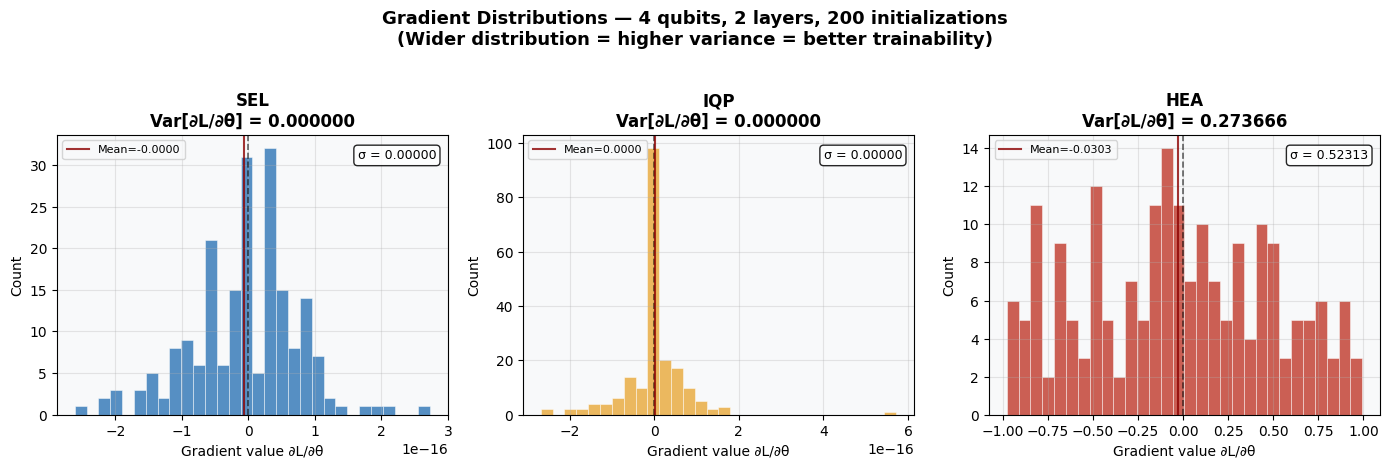

💾 Saved as 'gradient_distributions.png'


In [5]:
colors = {'SEL': '#2E75B6', 'IQP': '#E8A838', 'HEA': '#C0392B'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax, name in zip(axes, ['SEL', 'IQP', 'HEA']):
    grads = baseline_results[name]['gradients']
    var   = baseline_results[name]['variance']

    ax.hist(grads, bins=30, color=colors[name], alpha=0.8,
            edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.axvline(np.mean(grads), color='darkred', linestyle='-', linewidth=1.5,
               alpha=0.8, label=f'Mean={np.mean(grads):.4f}')

    ax.set_title(f'{name}\nVar[∂L/∂θ] = {var:.6f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Gradient value ∂L/∂θ', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)

    ax.text(0.97, 0.95,
            f'σ = {np.std(grads):.5f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

fig.suptitle(
    f'Gradient Distributions — {N_QUBITS} qubits, {N_LAYERS} layers, {N_INITS} initializations\n'
    f'(Wider distribution = higher variance = better trainability)',
    fontsize=13, fontweight='bold', y=1.03
)

plt.tight_layout()
plt.savefig('gradient_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved as 'gradient_distributions.png'")

---
## Cell 5 — Depth Sweep: Gradient Variance vs. Number of Layers

The key experiment. We expect to see gradient variance **decay** as layers increase, the faster it decays, the worse the barren plateau problem.

**Takes ~10–15 minutes**

In [6]:
depth_variance = {'SEL': [], 'IQP': [], 'HEA': []}
N_INITS_SWEEP = 100  # Reduced for speed

print(f"Depth sweep: 1 to {MAX_LAYERS_BP} layers, {N_INITS_SWEEP} inits per point")
print()

for n_layers in range(1, MAX_LAYERS_BP + 1):
    print(f"── Layers = {n_layers} ──")

    sel_fn_d, iqp_fn_d, hea_fn_d = make_circuits(N_QUBITS, n_layers)
    sel_s = qml.StronglyEntanglingLayers.shape(n_layers, N_QUBITS)
    iqp_s = (n_layers, N_QUBITS, 2)
    hea_s = (n_layers, N_QUBITS, 2)

    for name, fn, shape in [('SEL', sel_fn_d, sel_s), ('IQP', iqp_fn_d, iqp_s), ('HEA', hea_fn_d, hea_s)]:
        var, _ = measure_gradient_variance(fn, shape, N_INITS_SWEEP)
        depth_variance[name].append(var)
        print(f"  {name}: {var:.8f}")

print("\n✅ Depth sweep complete!")

Depth sweep: 1 to 8 layers, 100 inits per point

── Layers = 1 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.40500035
── Layers = 2 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.25633624
── Layers = 3 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.16142299
── Layers = 4 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.10617318
── Layers = 5 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.06069015
── Layers = 6 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.04208633
── Layers = 7 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.04004264
── Layers = 8 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.03483772

✅ Depth sweep complete!


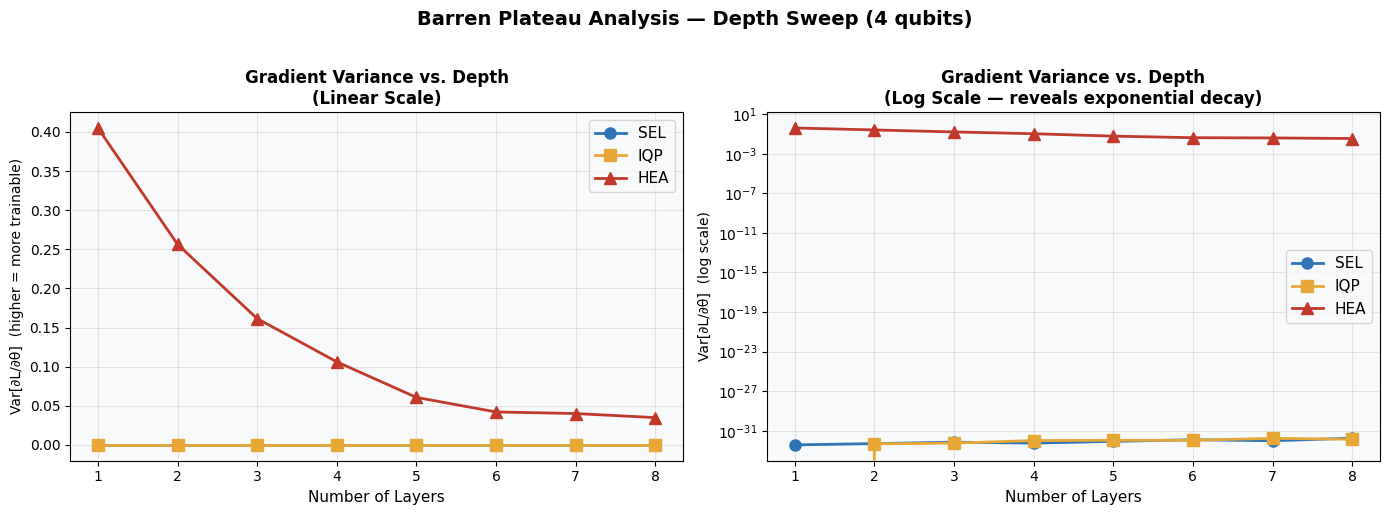

💾 Saved as 'barren_plateau_depth.png'


In [7]:
# Plot depth sweep — linear and log scale
layers_x = list(range(1, MAX_LAYERS_BP + 1))
markers  = {'SEL': 'o', 'IQP': 's', 'HEA': '^'}
colors_map = {'SEL': '#2E75B6', 'IQP': '#E8A838', 'HEA': '#C0392B'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in ['SEL', 'IQP', 'HEA']:
    ax1.plot(layers_x, depth_variance[name],
             color=colors_map[name], marker=markers[name],
             linewidth=2, markersize=8, label=name)

    # Log scale — reveals exponential decay clearly
    ax2.semilogy(layers_x, depth_variance[name],
                 color=colors_map[name], marker=markers[name],
                 linewidth=2, markersize=8, label=name)

ax1.set_xlabel('Number of Layers', fontsize=11)
ax1.set_ylabel('Var[∂L/∂θ]  (higher = more trainable)', fontsize=10)
ax1.set_title('Gradient Variance vs. Depth\n(Linear Scale)', fontsize=12, fontweight='bold')
ax1.set_xticks(layers_x)
ax1.legend(fontsize=11)

ax2.set_xlabel('Number of Layers', fontsize=11)
ax2.set_ylabel('Var[∂L/∂θ]  (log scale)', fontsize=10)
ax2.set_title('Gradient Variance vs. Depth\n(Log Scale — reveals exponential decay)', fontsize=12, fontweight='bold')
ax2.set_xticks(layers_x)
ax2.legend(fontsize=11)

fig.suptitle(f'Barren Plateau Analysis — Depth Sweep ({N_QUBITS} qubits)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('barren_plateau_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved as 'barren_plateau_depth.png'")

---
## Cell 6 — Width Sweep: Gradient Variance vs. Number of Qubits

 **Takes more than 30 minutes** (most expensive experiment)

In [8]:
width_variance  = {'SEL': [], 'IQP': [], 'HEA': []}
theoretical_decay = []  # 1/2^n reference line
N_INITS_WIDTH = 80
qubit_range   = range(2, MAX_QUBITS_BP + 1)

print(f"Width sweep: 2 to {MAX_QUBITS_BP} qubits, {N_LAYERS} layers, {N_INITS_WIDTH} inits per point")
print()

# Compute reference decay: normalize so n=2 value matches SEL at n=2
ref_value_at_2 = None

for n_qubits in qubit_range:
    print(f"── Qubits = {n_qubits} ──")
    theoretical_decay.append(1 / (2**n_qubits))

    sel_fn_w, iqp_fn_w, hea_fn_w = make_circuits(n_qubits, N_LAYERS)
    sel_s = qml.StronglyEntanglingLayers.shape(N_LAYERS, n_qubits)
    iqp_s = (N_LAYERS, n_qubits, 2)
    hea_s = (N_LAYERS, n_qubits, 2)

    for name, fn, shape in [('SEL', sel_fn_w, sel_s), ('IQP', iqp_fn_w, iqp_s), ('HEA', hea_fn_w, hea_s)]:
        var, _ = measure_gradient_variance(fn, shape, N_INITS_WIDTH)
        width_variance[name].append(var)
        print(f"  {name}: {var:.8f}")

print("\n✅ Width sweep complete!")

Width sweep: 2 to 8 qubits, 2 layers, 80 inits per point

── Qubits = 2 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.25281535
── Qubits = 3 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.32061062
── Qubits = 4 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.25992441
── Qubits = 5 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.28177555
── Qubits = 6 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.33074423
── Qubits = 7 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.29610770
── Qubits = 8 ──
  SEL: 0.00000000
  IQP: 0.00000000
  HEA: 0.29621338

✅ Width sweep complete!


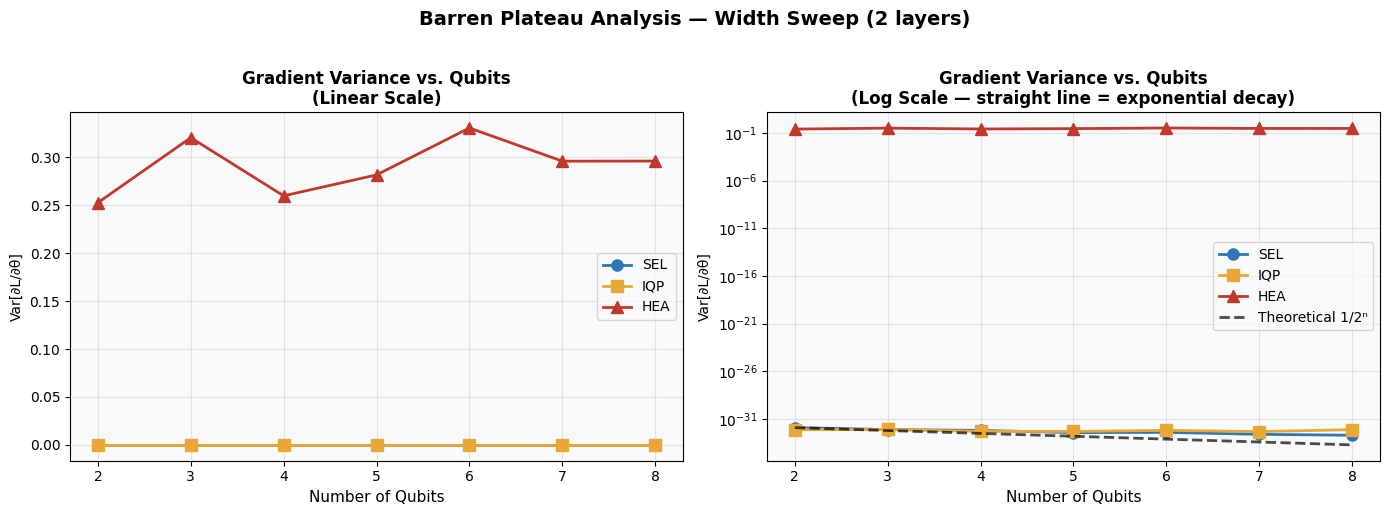

💾 Saved as 'barren_plateau_width.png'


In [9]:
# Plot width sweep with theoretical 1/2^n reference
qubits_x = list(qubit_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scale theoretical reference to match SEL at n=2
if width_variance['SEL'][0] > 0:
    scale = width_variance['SEL'][0] / theoretical_decay[0]
else:
    scale = 1.0
scaled_theory = [v * scale for v in theoretical_decay]

for name in ['SEL', 'IQP', 'HEA']:
    ax1.plot(qubits_x, width_variance[name],
             color=colors_map[name], marker=markers[name],
             linewidth=2, markersize=8, label=name)
    ax2.semilogy(qubits_x, width_variance[name],
                 color=colors_map[name], marker=markers[name],
                 linewidth=2, markersize=8, label=name)

# Add theoretical 1/2^n reference on log plot
ax2.semilogy(qubits_x, scaled_theory,
             color='black', linestyle='--', linewidth=2,
             label='Theoretical 1/2ⁿ', alpha=0.7)

for ax in (ax1, ax2):
    ax.set_xlabel('Number of Qubits', fontsize=11)
    ax.set_ylabel('Var[∂L/∂θ]', fontsize=10)
    ax.set_xticks(qubits_x)
    ax.legend(fontsize=10)

ax1.set_title('Gradient Variance vs. Qubits\n(Linear Scale)', fontsize=12, fontweight='bold')
ax2.set_title('Gradient Variance vs. Qubits\n(Log Scale — straight line = exponential decay)', fontsize=12, fontweight='bold')

fig.suptitle(f'Barren Plateau Analysis — Width Sweep ({N_LAYERS} layers)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('barren_plateau_width.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved as 'barren_plateau_width.png'")

---
## Cell 7 — The Key Plot: Expressibility vs. Trainability Tradeoff

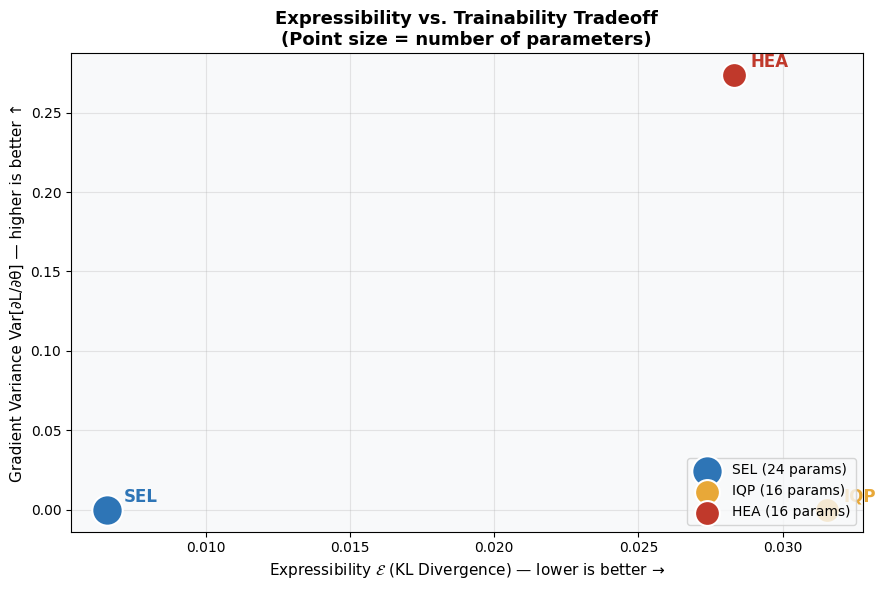

💾 Saved as 'expressibility_trainability_tradeoff.png'


In [ ]:
expressibility_scores = {
    'SEL': 0.006580,   
    'IQP': 0.031525,   
    'HEA': 0.028309    
}

trainability_scores = {
    name: baseline_results[name]['variance']
    for name in ['SEL', 'IQP', 'HEA']
}

param_counts = {
    'SEL': int(np.prod(qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS))),
    'IQP': N_LAYERS * N_QUBITS * 2,
    'HEA': N_LAYERS * N_QUBITS * 2
}

fig, ax = plt.subplots(figsize=(9, 6))

for name in ['SEL', 'IQP', 'HEA']:
    x = expressibility_scores[name]   # Lower = more expressive
    y = trainability_scores[name]     # Higher = more trainable
    p = param_counts[name]

    ax.scatter(x, y, color=colors_map[name], s=p*20,
               zorder=5, edgecolors='white', linewidth=1.5, label=f'{name} ({p} params)')
    ax.annotate(name,
                xy=(x, y), xytext=(12, 6),
                textcoords='offset points',
                fontsize=12, fontweight='bold', color=colors_map[name])

# Ideal region annotation
ax.annotate('← Ideal region\n(high expressibility\n+ high trainability)',
            xy=(0.002, max(trainability_scores.values()) * 0.9),
            fontsize=9, color='#27AE60', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', alpha=0.8))

# Arrows showing ideal direction
ax.annotate('', xy=(0.001, max(trainability_scores.values())*1.05),
            xytext=(min(expressibility_scores.values()), max(trainability_scores.values())*1.05),
            arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.5))

ax.set_xlabel('Expressibility $\\mathcal{E}$ (KL Divergence) — lower is better →', fontsize=11)
ax.set_ylabel('Gradient Variance Var[∂L/∂θ] — higher is better ↑', fontsize=11)
ax.set_title('Expressibility vs. Trainability Tradeoff\n(Point size = number of parameters)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('expressibility_trainability_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved as 'expressibility_trainability_tradeoff.png'")

---
## Cell 8 — Final Summary

In [11]:
print("=" * 70)
print(f"{'BARREN PLATEAU ANALYSIS — FULL SUMMARY':^70}")
print(f"Configuration: {N_QUBITS} qubits, {N_LAYERS} layers, {N_INITS} initializations")
print("=" * 70)
print(f"{'Circuit':<10} {'Expr. (E)':>12} {'Grad Var':>14} {'Params':>8} {'Verdict':>18}")
print("-" * 70)

verdicts = {
    'SEL': 'Expressive / Risky',
    'IQP': 'Balanced',
    'HEA': 'Trainable / Limited'
}

for name in ['SEL', 'IQP', 'HEA']:
    e  = expressibility_scores[name]
    gv = trainability_scores[name]
    p  = param_counts[name]
    v  = verdicts[name]
    print(f"{name:<10} {e:>12.6f} {gv:>14.8f} {p:>8} {v:>18}")

print("=" * 70)
print()
print("📌 Key findings:")
best_trainable = max(trainability_scores, key=trainability_scores.get)
best_expressive = min(expressibility_scores, key=expressibility_scores.get)
print(f"  • {best_expressive} is the most expressive but check its trainability")
print(f"  • {best_trainable} has the highest gradient variance (most trainable)")
print()
print("📌 Implications for VQC attention layers:")
print("  • If expressibility matters most → SEL (can represent diverse attention patterns)")
print("  • If trainability matters most → HEA or IQP (gradients survive longer)")
print("  • For a real transformer: start with HEA (trainable), increase depth carefully")
print()
print("📌 Mitigation strategies (for your thesis):")
print("  1. Local cost functions — use single-qubit measurements instead of global")
print("  2. Layerwise training — train one layer at a time, freeze the rest")
print("  3. Warm initialization — start near identity rather than random uniform")
print("  4. Shallow circuits — Notebook 02 showed 3 layers is the expressibility sweet spot")
print()
print("➡️  Next: Notebook 04 — Task Benchmark (classification performance)")

                BARREN PLATEAU ANALYSIS — FULL SUMMARY                
Configuration: 4 qubits, 2 layers, 200 initializations
Circuit       Expr. (E)       Grad Var   Params            Verdict
----------------------------------------------------------------------
SEL            0.006580     0.00000000       24 Expressive / Risky
IQP            0.031525     0.00000000       16           Balanced
HEA            0.028309     0.27366584       16 Trainable / Limited

📌 Key findings:
  • SEL is the most expressive but check its trainability
  • HEA has the highest gradient variance (most trainable)

📌 Implications for VQC attention layers:
  • If expressibility matters most → SEL (can represent diverse attention patterns)
  • If trainability matters most → HEA or IQP (gradients survive longer)
  • For a real transformer: start with HEA (trainable), increase depth carefully

📌 Mitigation strategies (for your thesis):
  1. Local cost functions — use single-qubit measurements instead of global


In [12]:
# ── Optional: Save to Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import shutil, os
save_dir = '/content/drive/MyDrive/quantum-attention-benchmark/results/'
os.makedirs(save_dir, exist_ok=True)
for f in ['gradient_distributions.png','barren_plateau_depth.png',
           'barren_plateau_width.png','expressibility_trainability_tradeoff.png']:
     shutil.copy(f, save_dir)

print("Notebook 03 complete! ✅")
print()
print("Plots generated:")
print("  ✓ gradient_distributions.png              — gradient histograms")
print("  ✓ barren_plateau_depth.png                — variance vs layers")
print("  ✓ barren_plateau_width.png                — variance vs qubits")
print("  ✓ expressibility_trainability_tradeoff.png — the thesis-level figure")

Mounted at /content/drive
Notebook 03 complete! ✅

Plots generated:
  ✓ gradient_distributions.png              — gradient histograms
  ✓ barren_plateau_depth.png                — variance vs layers
  ✓ barren_plateau_width.png                — variance vs qubits
  ✓ expressibility_trainability_tradeoff.png — the thesis-level figure
